# Machine Learning Assignment 2: Telco Customer Churn

**Student:** Sonali Samdarshini  
**BITS ID:** 2025AC05254  
**Dataset:** Telco Customer Churn  
**Target:** `Churn` (`No = 0`, `Yes = 1`)  
**Classification type:** Binary classification

This notebook documents the complete path from raw CSV to five saved deployment pipelines. The same reusable functions are also called by `model/train_models.py`, so notebook experiments and deployment artifacts cannot drift apart.

## Engineering goals

The workflow deliberately prevents common machine-learning mistakes:

- One fixed stratified 80/20 split is shared by all models.
- The held-out 20 percent is exported as `test_data.csv` and never used for fitting.
- Imputation, one-hot encoding, and scaling are inside scikit-learn pipelines.
- Preprocessors are fitted only on training folds, preventing leakage.
- Five-fold cross-validation is performed only on the training partition.
- The complete preprocessing-plus-model pipeline is saved for Streamlit deployment.
- Every saved model is reloaded and prediction-tested before it is accepted.

In [1]:
from pathlib import Path
import json
import platform
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display


def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / '..']
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / 'data' / 'telco_churn.csv').exists():
            return candidate
    raise FileNotFoundError('Could not locate data/telco_churn.csv from the current directory.')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ml_workflow import (
    MODEL_FILENAMES,
    MODEL_ORDER,
    NUMERIC_FEATURES,
    build_metadata,
    build_model_pipelines,
    clean_and_split_columns,
    cross_validate_models,
    evaluate_and_save_models,
    export_test_data,
    load_telco_dataset,
    split_dataset,
)

print('Project folder:', PROJECT_ROOT.name)
print('Python:', platform.python_version())
print('pandas:', pd.__version__)
print('NumPy:', np.__version__)
print('scikit-learn:', sklearn.__version__)
print('Joblib:', joblib.__version__)

Project folder: sonali_telco_churn_complete
Python: 3.13.5
pandas: 2.2.3
NumPy: 2.3.5
scikit-learn: 1.8.0
Joblib: 1.5.3


## 1. Load and inspect the public dataset

In [2]:
data_path = PROJECT_ROOT / 'data' / 'telco_churn.csv'
raw_df = load_telco_dataset(data_path)

print(f'Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns')
display(raw_df.head())

Raw shape: 7,043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print('Data types:')
display(raw_df.dtypes.rename('dtype').to_frame())

print('Raw pandas missing values:')
display(raw_df.isna().sum().rename('missing_count').to_frame())

print('Duplicate rows:', int(raw_df.duplicated().sum()))

print('Target counts and percentages:')
target_summary = pd.DataFrame({
    'count': raw_df['Churn'].value_counts(),
    'percentage': raw_df['Churn'].value_counts(normalize=True).mul(100),
})
display(target_summary.round(2))

print('Numeric summary before TotalCharges conversion:')
display(raw_df.describe().round(2))

Data types:


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Raw pandas missing values:


,missing_count
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Duplicate rows: 0
Target counts and percentages:


,count,percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


Numeric summary before TotalCharges conversion:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


### Important data-quality detail

`TotalCharges` is read as text because 11 rows contain blank strings. Ordinary `isna()` therefore reports zero missing values in the raw file. The cleaning function strips whitespace, converts this column to numeric, and turns invalid or blank text into `NaN`. Median imputation then happens inside each model pipeline using training data only.

In [4]:
X, y, customer_ids, cleaned_df = clean_and_split_columns(raw_df)

categorical_features = [column for column in X.columns if column not in NUMERIC_FEATURES]

print('Model feature shape:', X.shape)
print('Encoded target values:', sorted(y.unique().tolist()))
print('Missing TotalCharges after numeric conversion:', int(X['TotalCharges'].isna().sum()))
print('Numeric features:', NUMERIC_FEATURES)
print('Categorical feature count:', len(categorical_features))
print('Categorical features:', categorical_features)

display(X.head())

Model feature shape: (7043, 19)
Encoded target values: [0, 1]
Missing TotalCharges after numeric conversion: 11
Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical feature count: 15
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


## 2. Exploratory views

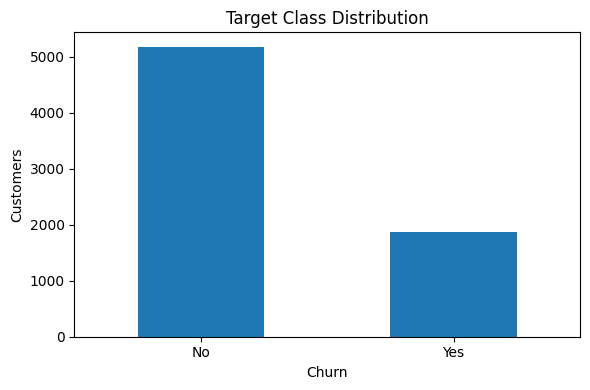

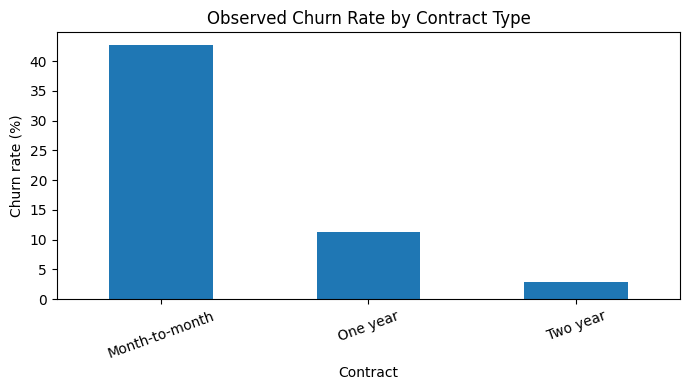

,churn_rate_percent
Contract,
Month-to-month,42.71
One year,11.27
Two year,2.83


In [5]:
target_counts = cleaned_df['Churn'].value_counts().reindex(['No', 'Yes'])
figure, axis = plt.subplots(figsize=(6, 4))
target_counts.plot(kind='bar', ax=axis)
axis.set_title('Target Class Distribution')
axis.set_xlabel('Churn')
axis.set_ylabel('Customers')
axis.tick_params(axis='x', rotation=0)
figure.tight_layout()
plt.show()

contract_churn = (
    cleaned_df.assign(ChurnFlag=cleaned_df['Churn'].map({'No': 0, 'Yes': 1}))
    .groupby('Contract')['ChurnFlag']
    .mean()
    .sort_values(ascending=False)
    .mul(100)
)
figure, axis = plt.subplots(figsize=(7, 4))
contract_churn.plot(kind='bar', ax=axis)
axis.set_title('Observed Churn Rate by Contract Type')
axis.set_xlabel('Contract')
axis.set_ylabel('Churn rate (%)')
axis.tick_params(axis='x', rotation=20)
figure.tight_layout()
plt.show()

display(contract_churn.rename('churn_rate_percent').round(2).to_frame())

The chart is descriptive, not causal. It shows association in this historical sample; it does not prove that changing a contract alone causes retention.

## 3. Create one stratified train-test split

In [6]:
X_train, X_test, y_train, y_test, id_train, id_test = split_dataset(
    X,
    y,
    customer_ids,
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('Training churn rate:', round(float(y_train.mean()), 4))
print('Test churn rate:', round(float(y_test.mean()), 4))

assert len(X_train) + len(X_test) == len(X)
assert list(X_train.columns) == list(X_test.columns)
assert abs(float(y_train.mean()) - float(y_test.mean())) < 0.01

Training rows: 5634
Test rows: 1409
Training churn rate: 0.2654
Test churn rate: 0.2654


In [7]:
test_data_path = PROJECT_ROOT / 'test_data.csv'
test_sha256 = export_test_data(X_test, y_test, id_test, test_data_path)

saved_test = pd.read_csv(test_data_path)
print('Saved test data:', test_data_path.relative_to(PROJECT_ROOT))
print('Saved test shape:', saved_test.shape)
print('SHA256:', test_sha256)
display(saved_test.head())

Saved test data: test_data.csv
Saved test shape: (1409, 21)
SHA256: 2e2634913de349f17ddae5151155d54856aa637e6b0875f274cc590252d8a8ac


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,No
1,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,No
2,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,No
3,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75,No
4,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,No


## 4. Build five independent pipelines

Each model receives a fresh `ColumnTransformer`. This avoids shared mutable preprocessing state. Logistic Regression, kNN, and Gaussian Naive Bayes scale numeric values. Decision Tree and Random Forest do not need numeric scaling. All models use median numeric imputation, most-frequent categorical imputation, and unknown-safe one-hot encoding.

In [8]:
pipelines = build_model_pipelines(X_train.columns.tolist())

for model_name in MODEL_ORDER:
    print()
    print('=' * 80)
    print(model_name)
    print(pipelines[model_name])


Logistic Regression
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('oneh

## 5. Five-fold cross-validation on training data only

Cross-validation estimates model stability without touching the final test partition. The submitted comparison table still uses the fixed held-out test set, as required by the assignment.

In [9]:
cv_metrics = cross_validate_models(pipelines, X_train, y_train)
cv_metrics_path = PROJECT_ROOT / 'cv_metrics.csv'
cv_metrics.to_csv(cv_metrics_path, index=False)

display(cv_metrics.round(4))

,Model,Accuracy_Mean,Accuracy_Std,AUC_Mean,AUC_Std,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F1_Mean,F1_Std,MCC_Mean,MCC_Std
0,Logistic Regression,0.8026,0.0131,0.8462,0.0141,0.6536,0.0280,0.5452,0.0469,0.5938,0.0339,0.4688,0.0400
1,Decision Tree,0.7914,0.0112,0.8289,0.0123,0.6345,0.0339,0.5130,0.0606,0.5649,0.0344,0.4359,0.0332
2,kNN,0.7888,0.0112,0.8330,0.0096,0.6061,0.0221,0.5833,0.0226,0.5944,0.0212,0.4519,0.0287
3,Naive Bayes,0.6967,0.0101,0.8212,0.0133,0.4612,0.0097,0.8482,0.0240,0.5974,0.0104,0.4331,0.0182
4,Random Forest,0.8051,0.0118,0.8475,0.0104,0.6781,0.0372,0.5084,0.0209,0.5807,0.0213,0.4654,0.0309


## 6. Fit, evaluate, save, and reload the five pipelines

In [10]:
model_directory = PROJECT_ROOT / 'model'
metrics_df, evaluation_details = evaluate_and_save_models(
    pipelines,
    X_train,
    y_train,
    X_test,
    y_test,
    model_directory,
)

metrics_path = PROJECT_ROOT / 'metrics.csv'
metrics_df.to_csv(metrics_path, index=False)

metadata = build_metadata(
    cleaned_df,
    X_train,
    X_test,
    y_train,
    y_test,
    metrics_df,
    test_sha256,
)

(model_directory / 'metadata.json').write_text(
    json.dumps(metadata, indent=2),
    encoding='utf-8',
)
(model_directory / 'evaluation_details.json').write_text(
    json.dumps(evaluation_details, indent=2),
    encoding='utf-8',
)

print('Required assignment comparison table:')
display(metrics_df.round(4))

Required assignment comparison table:


,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8077,0.8418,0.6604,0.5668,0.6101,0.4859
1,Decision Tree,0.7984,0.8303,0.6347,0.5668,0.5989,0.4662
2,kNN,0.7935,0.8285,0.6131,0.6016,0.6073,0.4672
3,Naive Bayes,0.6948,0.8074,0.4589,0.8369,0.5928,0.4245
4,Random Forest,0.8070,0.8444,0.6809,0.5134,0.5854,0.4706


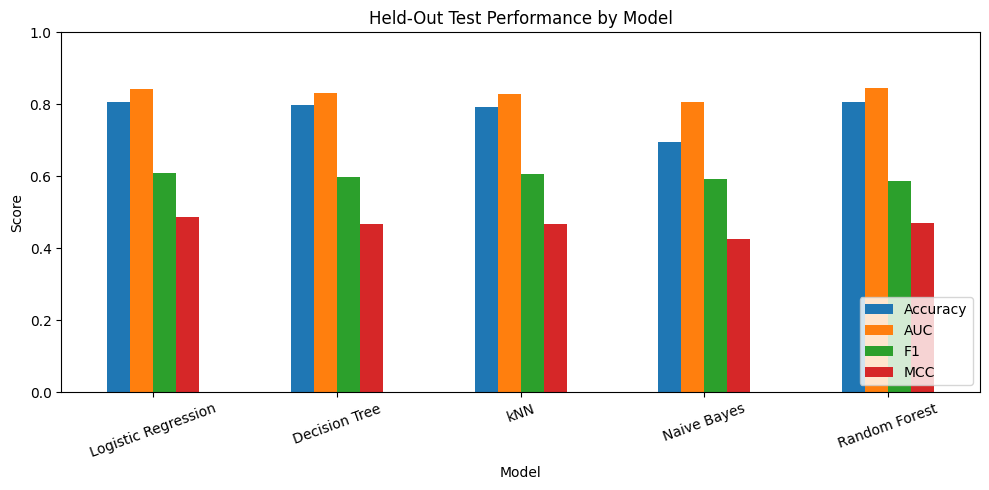

In [11]:
chart_data = metrics_df.set_index('Model')[['Accuracy', 'AUC', 'F1', 'MCC']]
figure, axis = plt.subplots(figsize=(10, 5))
chart_data.plot(kind='bar', ax=axis)
axis.set_title('Held-Out Test Performance by Model')
axis.set_xlabel('Model')
axis.set_ylabel('Score')
axis.set_ylim(0, 1)
axis.tick_params(axis='x', rotation=20)
axis.legend(loc='lower right')
figure.tight_layout()
plt.show()

## 7. Confusion matrices and classification reports

In [12]:
for model_name in MODEL_ORDER:
    details = evaluation_details[model_name]
    print()
    print('=' * 90)
    print(model_name)

    confusion = pd.DataFrame(
        details['confusion_matrix'],
        index=['Actual No Churn', 'Actual Churn'],
        columns=['Predicted No Churn', 'Predicted Churn'],
    )
    display(confusion)

    report = pd.DataFrame(details['classification_report']).transpose()
    display(report[['precision', 'recall', 'f1-score', 'support']].round(4))


Logistic Regression


,Predicted No Churn,Predicted Churn
Actual No Churn,926,109
Actual Churn,162,212


,precision,recall,f1-score,support
No Churn,0.8511,0.8947,0.8724,1035.0000
Churn,0.6604,0.5668,0.6101,374.0000
accuracy,0.8077,0.8077,0.8077,0.8077
macro avg,0.7558,0.7308,0.7412,1409.0000
weighted avg,0.8005,0.8077,0.8027,1409.0000



Decision Tree


,Predicted No Churn,Predicted Churn
Actual No Churn,913,122
Actual Churn,162,212


...

,Predicted No Churn,Predicted Churn
Actual No Churn,666,369
Actual Churn,61,313


,precision,recall,f1-score,support
No Churn,0.9161,0.6435,0.7560,1035.0000
Churn,0.4589,0.8369,0.5928,374.0000
accuracy,0.6948,0.6948,0.6948,0.6948
macro avg,0.6875,0.7402,0.6744,1409.0000
weighted avg,0.7947,0.6948,0.7127,1409.0000



Random Forest


,Predicted No Churn,Predicted Churn
Actual No Churn,945,90
Actual Churn,182,192


,precision,recall,f1-score,support
No Churn,0.8385,0.9130,0.8742,1035.000
Churn,0.6809,0.5134,0.5854,374.000
accuracy,0.8070,0.8070,0.8070,0.807
macro avg,0.7597,0.7132,0.7298,1409.000
weighted avg,0.7967,0.8070,0.7975,1409.000


## 8. Evidence-based observations

In [13]:
observations = metadata['observations']
observation_table = pd.DataFrame(
    [
        {'ML Model Name': model_name, 'Observation': observations[model_name]}
        for model_name in MODEL_ORDER
    ]
    + [
        {'ML Model Name': 'Overall Winner', 'Observation': observations['Overall Winner']}
    ]
)
display(observation_table)

print('Best AUC model:', observations['Best AUC Model'])
print('Best recall model:', observations['Best Recall Model'])
print('Best precision model:', observations['Best Precision Model'])

,ML Model Name,Observation
0,Logistic Regression,Strong balanced baseline with the highest comb...
1,Decision Tree,"Competitive and interpretable, but a single tr..."
2,kNN,Scaling is essential because prediction is dis...
3,Naive Bayes,Produces the highest recall (0.8369) but many ...
4,Random Forest,Provides the best AUC (0.8444) and strong prec...
5,Overall Winner,Logistic Regression. It has the best average r...


Best AUC model: Random Forest
Best recall model: Naive Bayes
Best precision model: Random Forest


## 9. Artifact verification

In [14]:
required_paths = [
    PROJECT_ROOT / 'metrics.csv',
    PROJECT_ROOT / 'cv_metrics.csv',
    PROJECT_ROOT / 'test_data.csv',
    PROJECT_ROOT / 'model' / 'metadata.json',
    PROJECT_ROOT / 'model' / 'evaluation_details.json',
]
required_paths.extend(
    PROJECT_ROOT / 'model' / MODEL_FILENAMES[model_name]
    for model_name in MODEL_ORDER
)

verification_rows = []
for path in required_paths:
    verification_rows.append({
        'artifact': str(path.relative_to(PROJECT_ROOT)),
        'exists': path.exists(),
        'size_kb': round(path.stat().st_size / 1024, 2) if path.exists() else None,
    })

display(pd.DataFrame(verification_rows))
assert all(row['exists'] for row in verification_rows)

sample = X_test.iloc[:1]
for model_name in MODEL_ORDER:
    path = PROJECT_ROOT / 'model' / MODEL_FILENAMES[model_name]
    loaded_pipeline = joblib.load(path)
    prediction = int(loaded_pipeline.predict(sample)[0])
    probability = float(loaded_pipeline.predict_proba(sample)[0, 1])
    print(f'{model_name:20s} prediction={prediction} churn_probability={probability:.4f}')

,artifact,exists,size_kb
0,metrics.csv,True,0.66
1,cv_metrics.csv,True,1.36
2,test_data.csv,True,190.25
3,model/metadata.json,True,5.28
4,model/evaluation_details.json,True,5.59
5,model/logistic_regression.joblib,True,2.62
6,model/decision_tree.joblib,True,4.43
7,model/knn.joblib,True,211.59
8,model/naive_bayes.joblib,True,3.41
9,model/random_forest.joblib,True,2043.98


Logistic Regression  prediction=0 churn_probability=0.0464
Decision Tree        prediction=0 churn_probability=0.0000
kNN                  prediction=0 churn_probability=0.0000
Naive Bayes          prediction=0 churn_probability=0.0000


Random Forest        prediction=0 churn_probability=0.0258


## Conclusion

All five listed classifiers were trained on the same dataset and the same fixed split. Logistic Regression is the overall winner by average rank across Accuracy, AUC, F1, and MCC. Random Forest has the highest AUC, while Naive Bayes has the highest recall but substantially lower precision. The complete pipelines, test CSV, metrics, metadata, and Streamlit-ready artifacts are now available in the repository.

The next executable step is:

```bash
python -m streamlit run app.py
```

The Streamlit UI supports model selection, CSV upload, live metrics, confusion matrix, classification report, downloadable predictions, threshold control, and a single-customer simulator.